# Sonar MOT — Fish & Net Presence Plots
**[This is made with claude]**

**Sonar perspective:** The ROV sonar is at the **bottom** of the image, looking **upward**.  
Range (distance from sonar) increases **upward** in pixel space (row 699 ≈ 0 m, row 0 ≈ 8 m).  
The net typically appears as a wide, nearly-horizontal band across the image.

**Classes:** `1 = fish`, `2 = net`

**Physical mapping** (from `net_sonar_labelingview_config`):
- Image size: 1200 × 700 px  
- Cone view range: 0 – 8 m (row 0 ≈ 0 m, row 699 ≈ 8 m)  
- Cone view angle: ±45° → x_span = 8 × sin(45°) ≈ 5.66 m each side

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from pathlib import Path

In [2]:
# ── Physical mapping constants (from net_sonar_labelingview_config) ──────────
IMG_W, IMG_H      = 1200, 700
Y_MAX_M           = 8.0          # coneview_range_max_m
AHALF_DEG         = 45.0         # half of coneview angle window
X_SPAN_M          = Y_MAX_M * np.sin(np.deg2rad(AHALF_DEG))  # ≈ 5.657 m

def px_to_m(cx_px, cy_px):
    """Convert pixel bbox centre to physical (x_m, y_m, range_m).
    Sonar is at the BOTTOM of the image (row 699 ≈ 0 m), looking upward.
    y_m = range from sonar: row 699 = 0 m, row 0 = Y_MAX_M.
    x_m = lateral offset: col 0 = -X_SPAN_M, col 1199 = +X_SPAN_M.
    """
    y_m   = (IMG_H - 1 - cy_px) * (Y_MAX_M / (IMG_H - 1))
    x_m   = cx_px * (2 * X_SPAN_M / IMG_W) - X_SPAN_M
    rng_m = np.sqrt(x_m**2 + y_m**2)
    return x_m, y_m, rng_m

def width_px_to_m(w_px):
    return w_px * (2 * X_SPAN_M / IMG_W)

def height_px_to_m(h_px):
    return h_px * (Y_MAX_M / IMG_H)

print(f"x_span = {X_SPAN_M:.3f} m  →  {IMG_W} px = {2*X_SPAN_M:.3f} m  ({2*X_SPAN_M/IMG_W*100:.2f} cm/px)")
print(f"y range = {Y_MAX_M} m  →  {IMG_H} px  ({Y_MAX_M/IMG_H*100:.2f} cm/px)")

x_span = 5.657 m  →  1200 px = 11.314 m  (0.94 cm/px)
y range = 8.0 m  →  700 px  (1.14 cm/px)


In [3]:
MOT_ROOT = Path(".")   # run from sonar/MOT/ or set absolute path
GT_COLS  = ["frame_id", "track_id", "x", "y", "w", "h", "not_ignored", "class_id", "visibility"]

CLASS_NAMES  = {1: "fish", 2: "net"}
CLASS_COLORS = {1: "steelblue", 2: "tomato"}

sequences = sorted([p for p in MOT_ROOT.iterdir() if p.is_dir()])
print(f"Found {len(sequences)} sequences:")
for s in sequences:
    print(" ", s.name)

Found 5 sequences:
  2024-08-20_14-31-29
  2024-08-20_17-02-00
  2024-08-20_17-14-36
  2024-08-20_17-39-32
  2024-08-20_17-55-40


In [4]:
def load_gt(seq_path: Path) -> pd.DataFrame:
    """Load gt/gt.txt mapping frame_ids to sequential frame numbers via image filenames.
    Sonar frames are directly in frames/ (no sequence-name subdirectory).
    Also adds physical metre coordinates derived from the sonar mapping config.
    """
    img_files = sorted((seq_path / "frames").glob("*.jpg"))
    frame_id_to_num = {int(f.stem): i + 1 for i, f in enumerate(img_files)}

    df = pd.read_csv(seq_path / "gt" / "gt.txt", header=None, names=GT_COLS)
    df["sequence"]     = seq_path.name
    df["total_frames"] = len(img_files)
    df["frame_norm"]   = df["frame_id"].map(frame_id_to_num)

    df["cx"] = df["x"] + df["w"] / 2
    df["cy"] = df["y"] + df["h"] / 2

    df["x_m"], df["y_m"], df["range_m"] = px_to_m(df["cx"], df["cy"])
    df["w_m"] = width_px_to_m(df["w"])
    df["h_m"] = height_px_to_m(df["h"])
    # Near edge of bbox (closest point to sonar = bottom edge of bbox, since sonar is below)
    df["y_near_m"] = np.maximum(0.0, (IMG_H - 1 - (df["y"] + df["h"])) * (Y_MAX_M / (IMG_H - 1)))
    return df

all_dfs  = [load_gt(s) for s in sequences]
all_data = pd.concat(all_dfs, ignore_index=True)
fish_data = all_data[all_data["class_id"] == 1].copy()
net_data  = all_data[all_data["class_id"] == 2].copy()

print(f"Total annotations: {len(all_data):,}")
print(f"Fish:              {len(fish_data):,}")
print(f"Net:               {len(net_data):,}")

Total annotations: 6,852
Fish:              2,871
Net:               3,981


## 1  Dataset summary

In [5]:
rows = []
for df in all_dfs:
    seq   = df["sequence"].iloc[0]
    total = int(df["total_frames"].iloc[0])
    fish  = df[df["class_id"] == 1]
    net   = df[df["class_id"] == 2]
    rows.append({
        "Sequence":        seq,
        "Total frames":    total,
        "Fish annots":     len(fish),
        "Fish tracks":     fish["track_id"].nunique(),
        "Net annots":      len(net),
        "Net tracks":      net["track_id"].nunique(),
        "Net range mean (m)": round(net["range_m"].mean(), 2) if len(net) else float("nan"),
        "Net width mean (m)": round(net["w_m"].mean(), 2)    if len(net) else float("nan"),
    })

summary = pd.DataFrame(rows)
display(summary)

,Sequence,Total frames,Fish annots,Fish tracks,Net annots,Net tracks,Net range mean (m),Net width mean (m)
0,2024-08-20_14-31-29,1060,946,30,1060,1,2.08,3.65
1,2024-08-20_17-02-00,860,442,11,860,1,1.08,2.21
2,2024-08-20_17-14-36,673,457,14,673,1,1.23,2.47
3,2024-08-20_17-39-32,607,246,13,607,1,0.98,2.03
4,2024-08-20_17-55-40,781,780,24,781,1,1.18,2.38


## 2  Fish & net count per frame

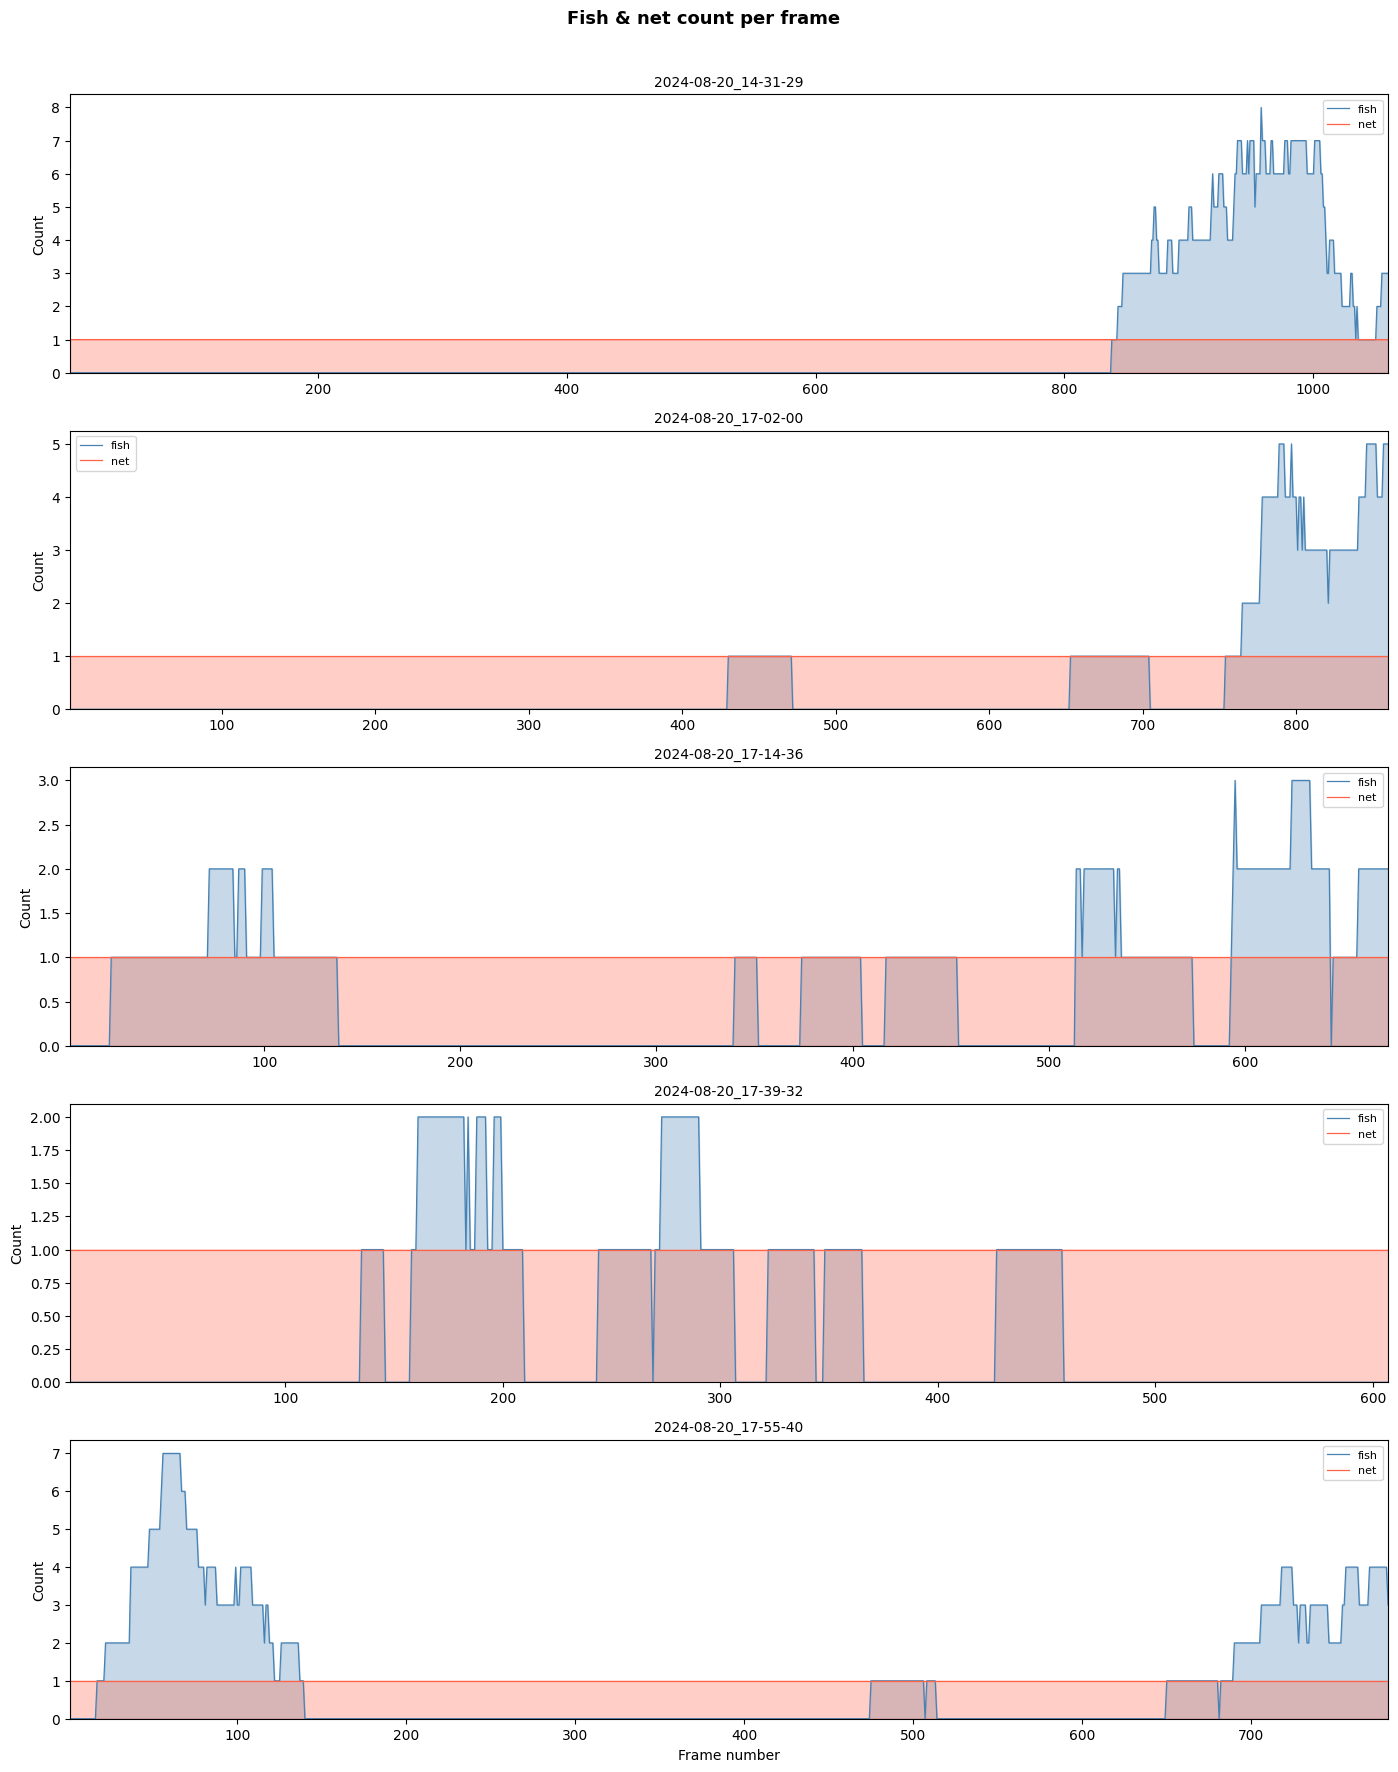

In [6]:
fig, axes = plt.subplots(len(all_dfs), 1, figsize=(14, 3.5 * len(all_dfs)), sharex=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq   = df["sequence"].iloc[0]
    total = int(df["total_frames"].iloc[0])
    all_frames = pd.Series(range(1, total + 1), name="frame_norm")

    for cls, color, label in [(1, "steelblue", "fish"), (2, "tomato", "net")]:
        cnt = df[df["class_id"] == cls].groupby("frame_norm").size().reindex(all_frames, fill_value=0)
        ax.fill_between(cnt.index, cnt.values, alpha=0.3, color=color)
        ax.plot(cnt.index, cnt.values, lw=0.9, color=color, label=label)

    ax.set_ylabel("Count")
    ax.set_title(seq, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(1, total)
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Frame number")
fig.suptitle("Fish & net count per frame", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("count_per_frame.png", dpi=150, bbox_inches="tight")
plt.show()

## 3  Net distance from sonar over time
The sonar looks from above. The **range** of the net (distance from the sonar head) is the key spatial measurement — it changes as the net drifts or the vessel moves.

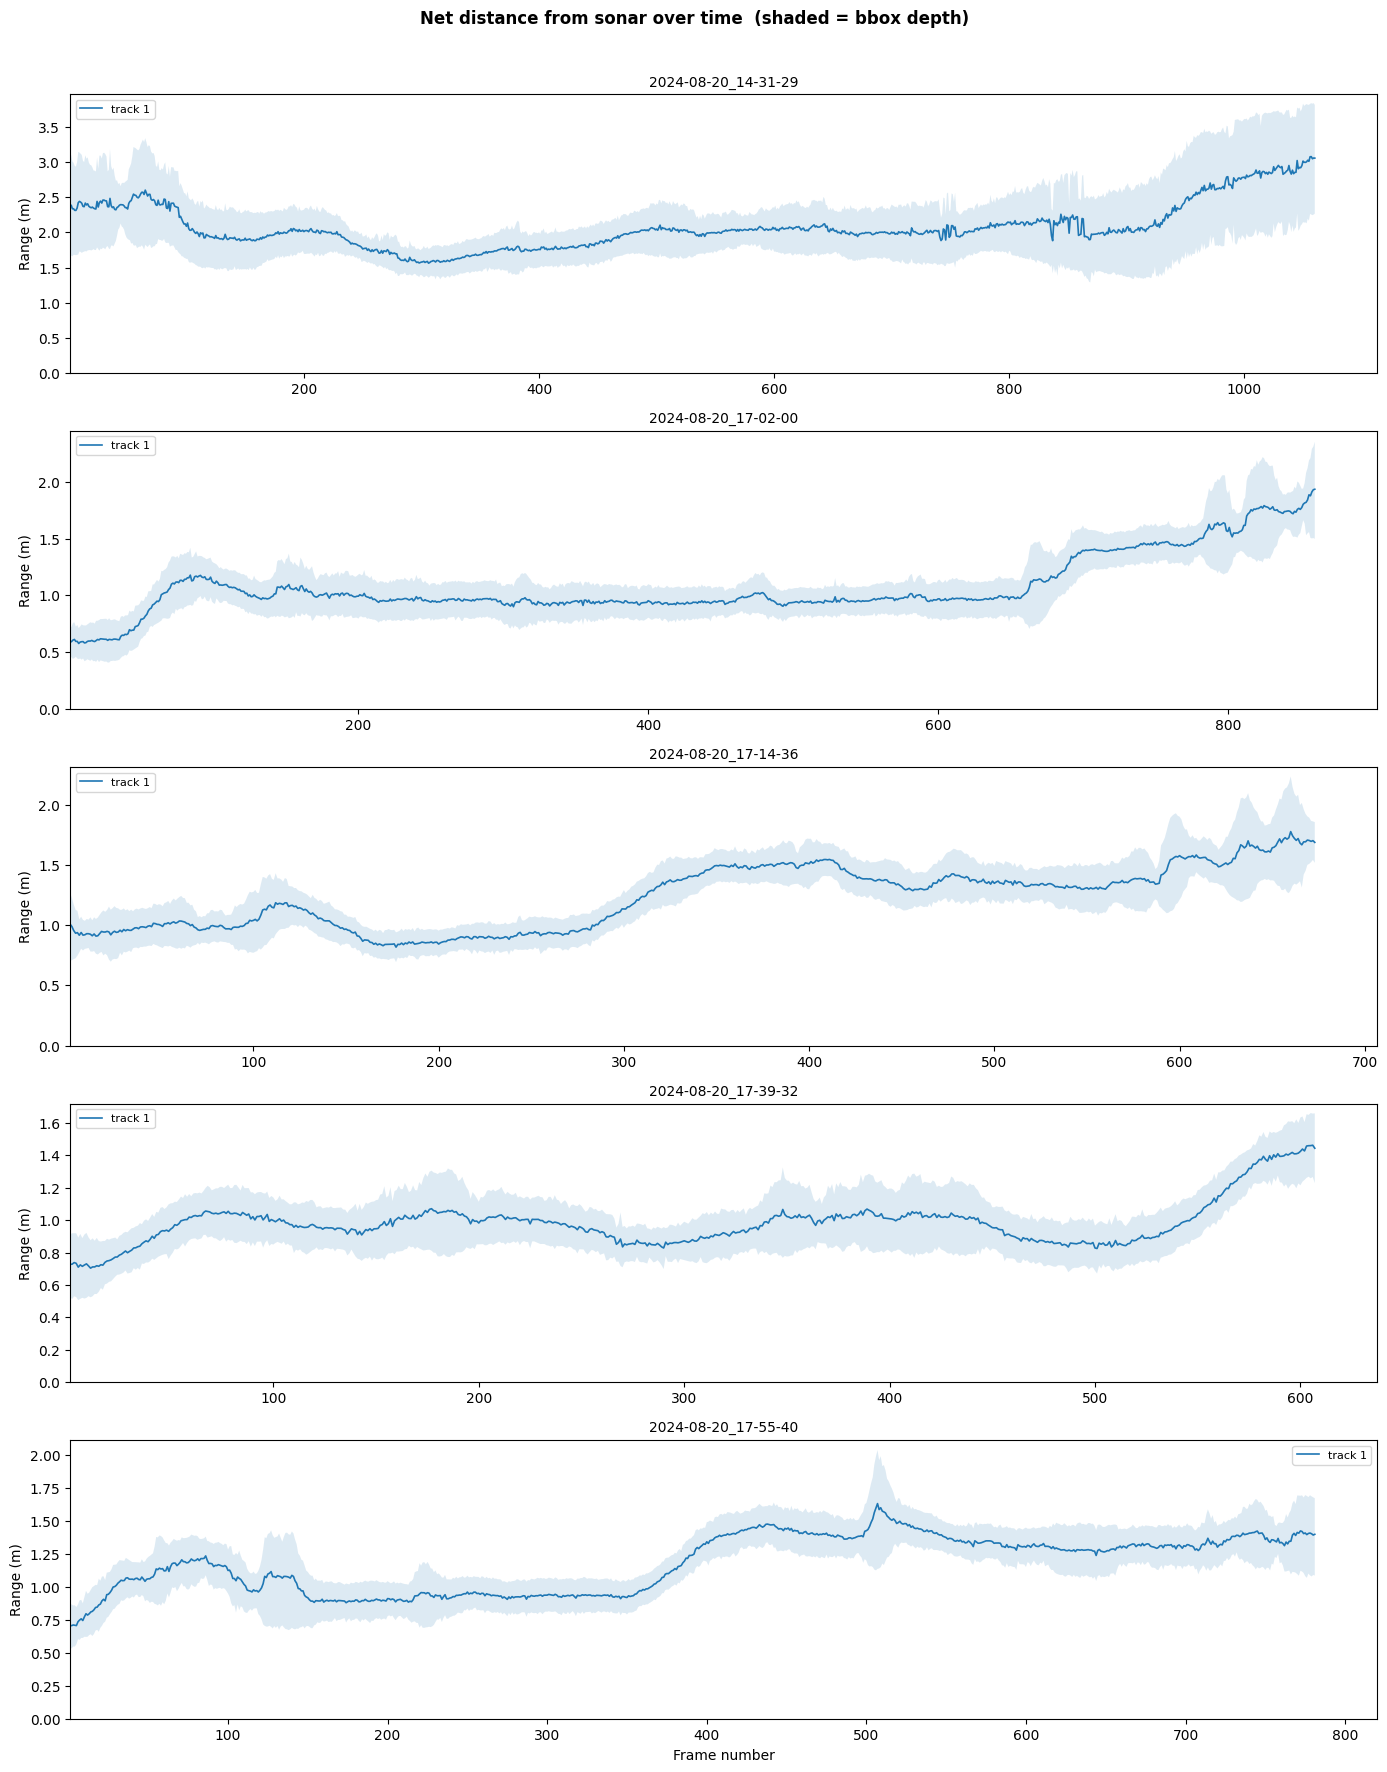

In [7]:
fig, axes = plt.subplots(len(all_dfs), 1, figsize=(14, 3.5 * len(all_dfs)), sharex=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    net = df[df["class_id"] == 2].sort_values("frame_norm")
    if net.empty:
        ax.set_title(f"{seq} — no net annotations", fontsize=10)
        continue

    # Per-track line (there may be multiple net tracks)
    for tid, grp in net.groupby("track_id"):
        grp = grp.sort_values("frame_norm")
        ax.plot(grp["frame_norm"], grp["range_m"], lw=1.2, label=f"track {tid}")
        # Shade between near and far edge
        ax.fill_between(
            grp["frame_norm"],
            grp["y_near_m"],
            grp["y_near_m"] + grp["h_m"],
            alpha=0.15, label="_"
        )

    ax.set_ylabel("Range (m)")
    ax.set_title(seq, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(left=1)
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Frame number")
fig.suptitle("Net distance from sonar over time  (shaded = bbox depth)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("net_range_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 4  Net width and lateral position over time

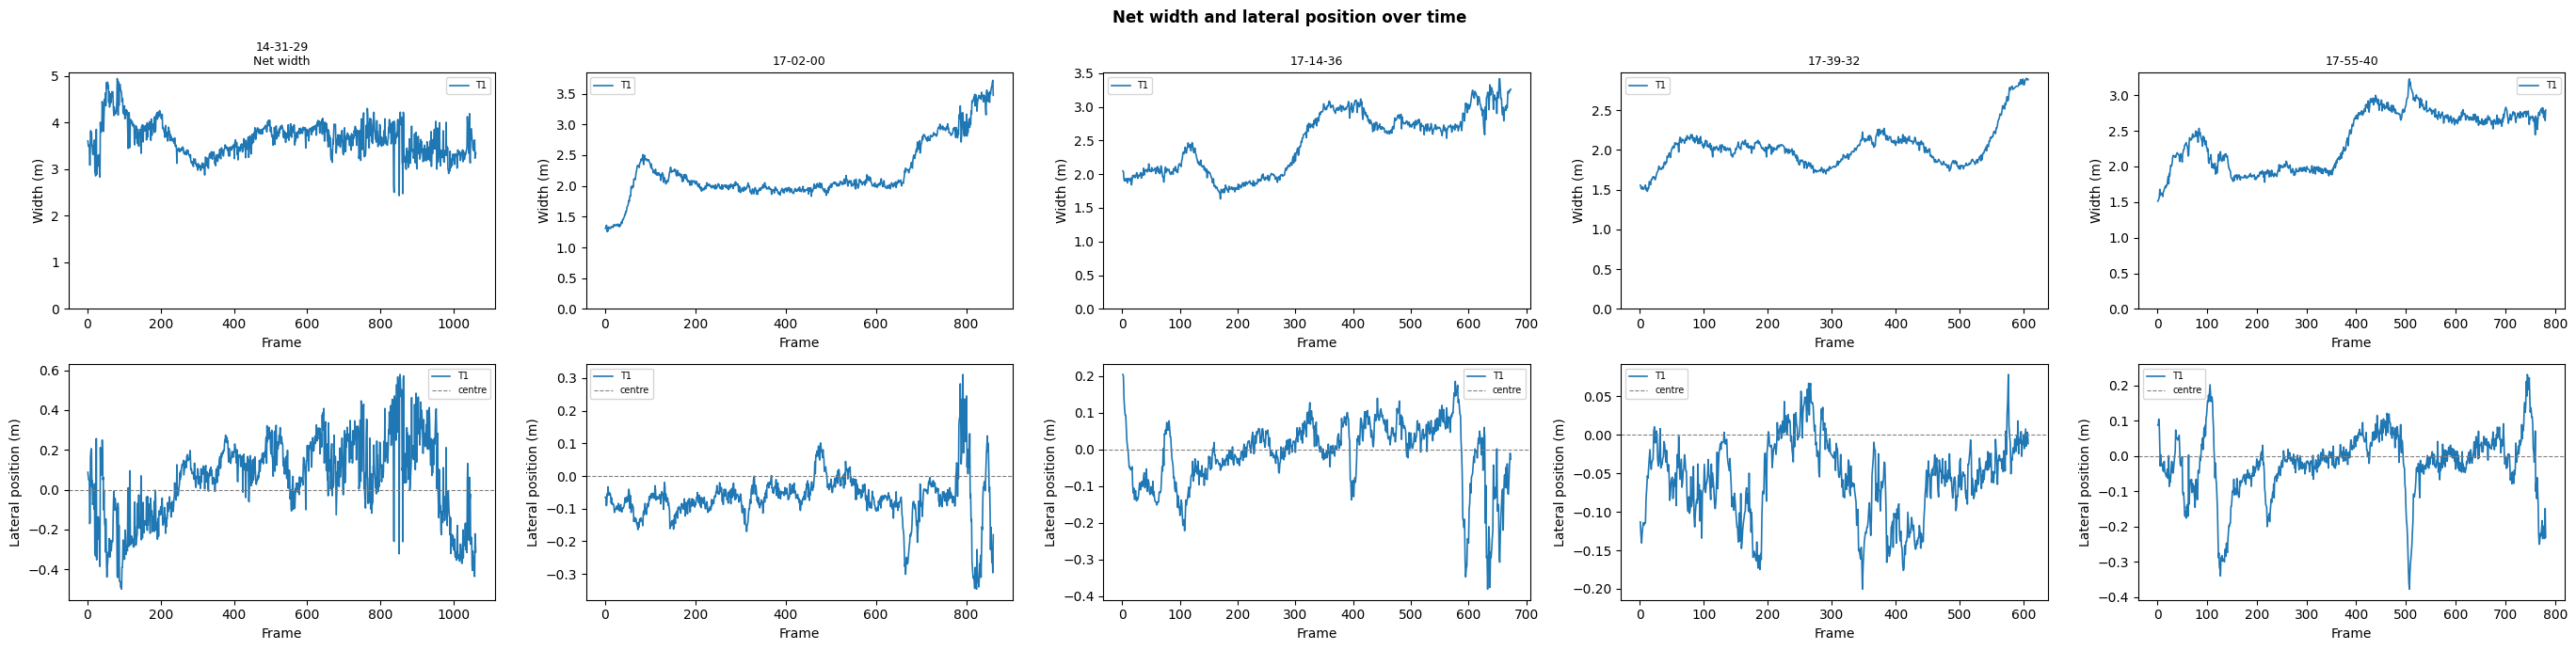

In [8]:
fig, axes = plt.subplots(2, len(all_dfs), figsize=(5.5 * len(all_dfs), 7))

for col, df in enumerate(all_dfs):
    seq = df["sequence"].iloc[0]
    net = df[df["class_id"] == 2].sort_values("frame_norm")

    # Row 0: net width in metres
    ax = axes[0, col]
    if not net.empty:
        for tid, grp in net.groupby("track_id"):
            ax.plot(grp["frame_norm"], grp["w_m"], lw=1.2, label=f"T{tid}")
    ax.set_ylabel("Width (m)")
    ax.set_title(seq[-8:], fontsize=9)
    ax.set_xlabel("Frame")
    ax.legend(fontsize=7)
    ax.set_ylim(bottom=0)

    # Row 1: net lateral centre position in metres (x_m)
    ax = axes[1, col]
    if not net.empty:
        for tid, grp in net.groupby("track_id"):
            ax.plot(grp["frame_norm"], grp["x_m"], lw=1.2, label=f"T{tid}")
        ax.axhline(0, color="gray", lw=0.8, ls="--", label="centre")
    ax.set_ylabel("Lateral position (m)")
    ax.set_xlabel("Frame")
    ax.legend(fontsize=7)

axes[0, 0].set_title(f"{all_dfs[0]['sequence'].iloc[0][-8:]}\nNet width", fontsize=9)
fig.suptitle("Net width and lateral position over time", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("net_width_lateral.png", dpi=150, bbox_inches="tight")
plt.show()

## 5  Fish & net positions in physical space (top-down, metres)
The sonar head is at (0, 0). The net appears as a horizontal band; fish are individual blobs.

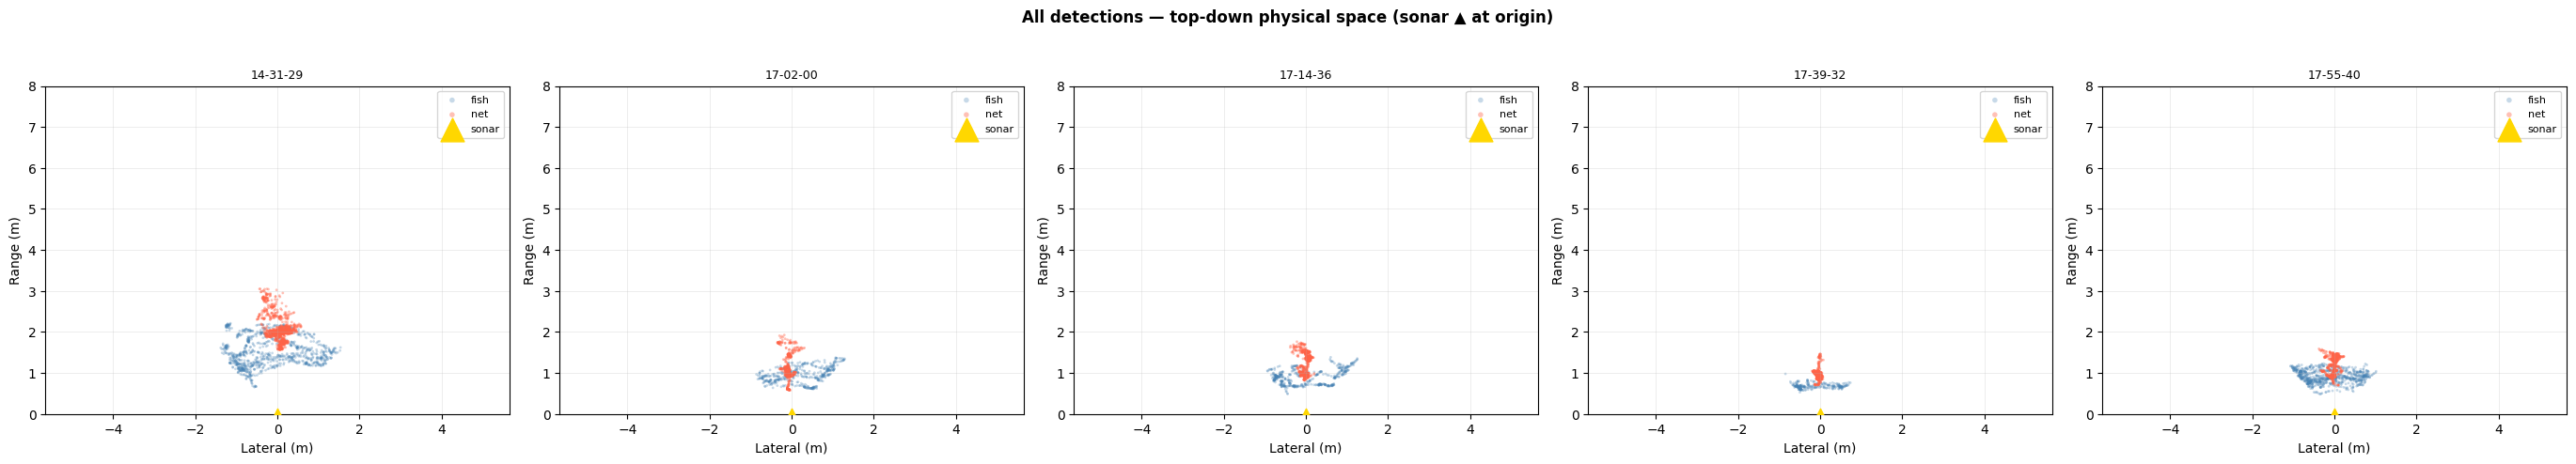

In [9]:
fig, axes = plt.subplots(1, len(all_dfs), figsize=(5.5 * len(all_dfs), 5))
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq  = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1]
    net  = df[df["class_id"] == 2]

    ax.scatter(fish["x_m"], fish["y_m"], s=4, alpha=0.3, color="steelblue",
               edgecolors="none", label="fish")
    ax.scatter(net["x_m"],  net["y_m"],  s=4, alpha=0.4, color="tomato",
               edgecolors="none", label="net")

    # Mark sonar position
    ax.scatter(0, 0, s=80, color="gold", marker="^", zorder=5, label="sonar")

    ax.set_xlim(-X_SPAN_M, X_SPAN_M)
    ax.set_ylim(0, Y_MAX_M)
    ax.set_xlabel("Lateral (m)")
    ax.set_ylabel("Range (m)")
    ax.set_title(seq[-8:], fontsize=9)
    ax.set_aspect("equal")
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(True, lw=0.4, alpha=0.4)

fig.suptitle("All detections — top-down physical space (sonar ▲ at origin)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("spatial_topdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 6  Fish track trajectories (top-down, metres)

/tmp/ipykernel_12212/1519750187.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = cm.get_cmap("tab20", len(track_ids))
/tmp/ipykernel_12212/1519750187.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = cm.get_cmap("tab20", len(track_ids))
/tmp/ipykernel_12212/1519750187.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = cm.get_cmap("tab20", len(track_ids))
/tmp/ipykernel_12212/1519750187.py:11: MatplotlibDeprecationWarn

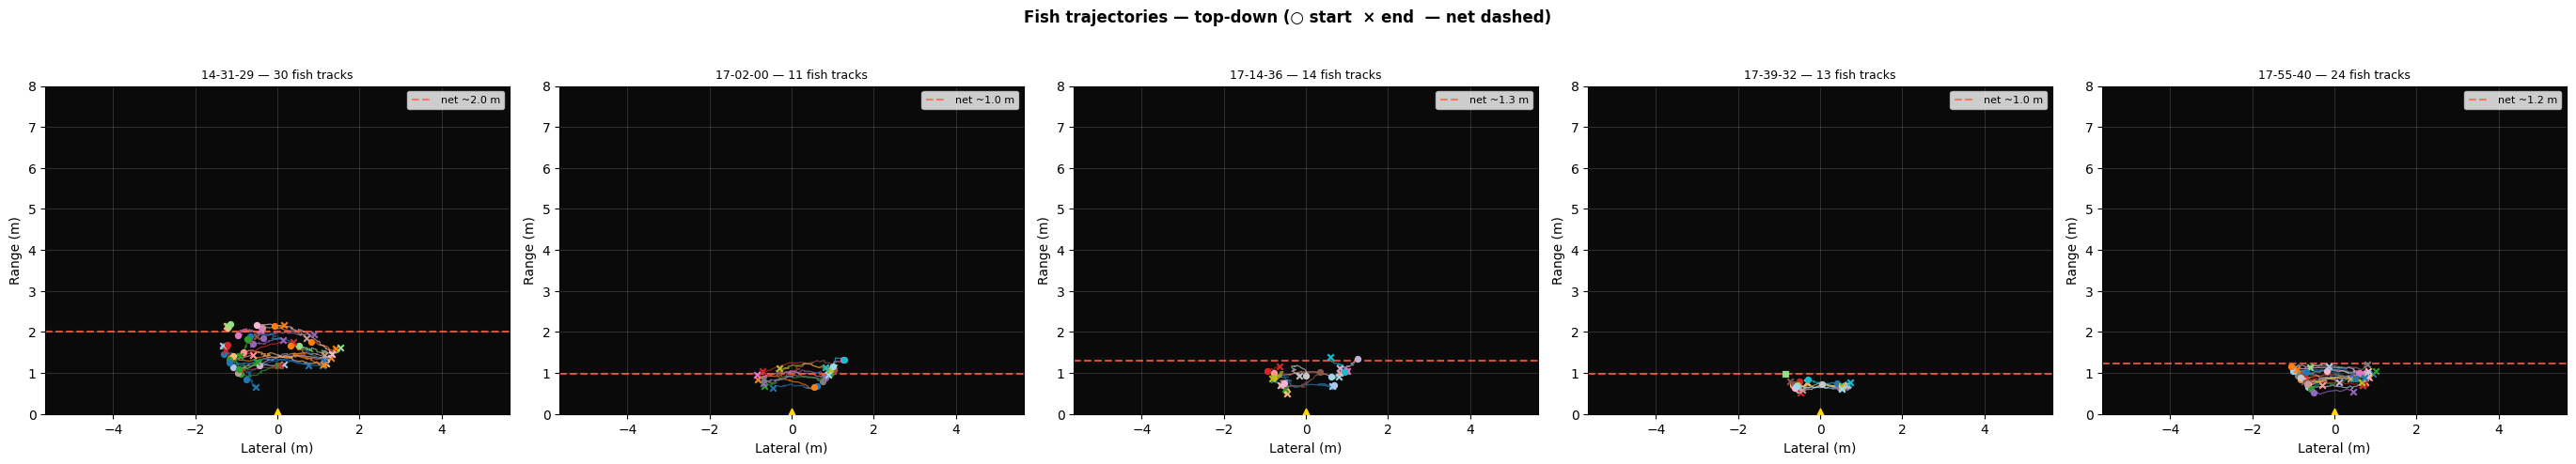

In [10]:
fig, axes = plt.subplots(1, len(all_dfs), figsize=(5.5 * len(all_dfs), 5))
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq  = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1].sort_values(["track_id", "frame_norm"])
    net  = df[df["class_id"] == 2]

    track_ids = sorted(fish["track_id"].unique())
    cmap      = cm.get_cmap("tab20", len(track_ids))

    for i, (tid, grp) in enumerate(fish.groupby("track_id")):
        c = cmap(i % 20)
        ax.plot(grp["x_m"], grp["y_m"], lw=0.9, alpha=0.7, color=c)
        ax.scatter(grp["x_m"].iloc[0],  grp["y_m"].iloc[0],  s=18, color=c, marker="o", zorder=3)
        ax.scatter(grp["x_m"].iloc[-1], grp["y_m"].iloc[-1], s=22, color=c, marker="x", zorder=3)

    # Show net mean position as a dashed line
    if not net.empty:
        net_y = net["y_m"].median()
        ax.axhline(net_y, color="tomato", lw=1.5, ls="--", alpha=0.8, label=f"net ~{net_y:.1f} m")

    ax.scatter(0, 0, s=80, color="gold", marker="^", zorder=5)
    ax.set_xlim(-X_SPAN_M, X_SPAN_M)
    ax.set_ylim(0, Y_MAX_M)
    ax.set_xlabel("Lateral (m)")
    ax.set_ylabel("Range (m)")
    ax.set_title(f"{seq[-8:]} — {len(track_ids)} fish tracks", fontsize=9)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.4)
    ax.set_facecolor("#0a0a0a")

fig.suptitle("Fish trajectories — top-down (○ start  × end  — net dashed)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_trajectories_topdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  Fish distance from sonar over time

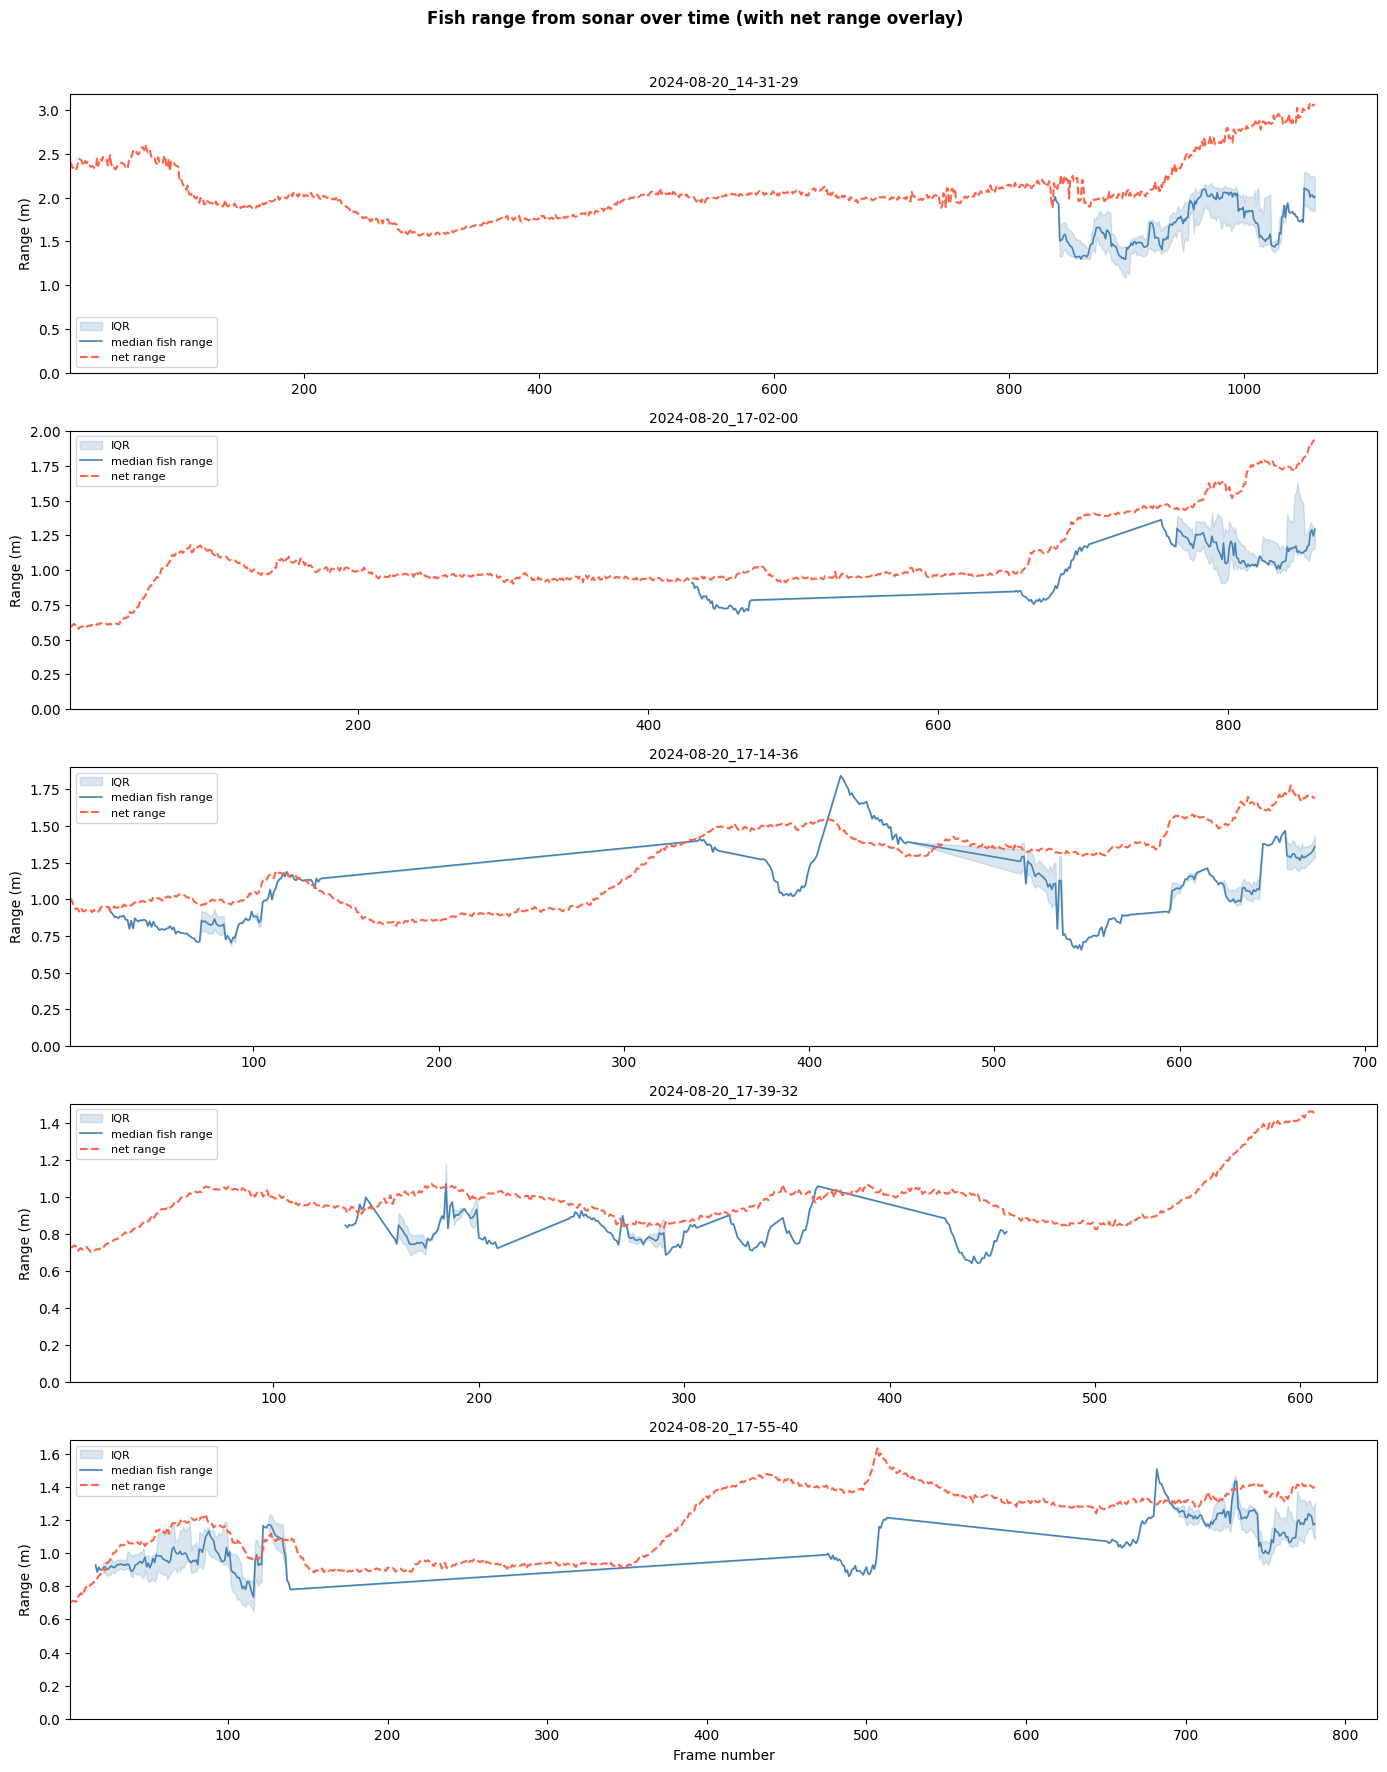

In [11]:
fig, axes = plt.subplots(len(all_dfs), 1, figsize=(14, 3.5 * len(all_dfs)), sharex=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq  = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1].sort_values("frame_norm")
    net  = df[df["class_id"] == 2]

    # Per-frame median fish range
    med  = fish.groupby("frame_norm")["range_m"].median()
    q25  = fish.groupby("frame_norm")["range_m"].quantile(0.25)
    q75  = fish.groupby("frame_norm")["range_m"].quantile(0.75)

    ax.fill_between(med.index, q25.values, q75.values, alpha=0.2, color="steelblue", label="IQR")
    ax.plot(med.index, med.values, lw=1.2, color="steelblue", label="median fish range")

    if not net.empty:
        net_med = net.groupby("frame_norm")["range_m"].median()
        ax.plot(net_med.index, net_med.values, lw=1.5, ls="--", color="tomato", label="net range")

    ax.set_ylabel("Range (m)")
    ax.set_title(seq, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(left=1)
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Frame number")
fig.suptitle("Fish range from sonar over time (with net range overlay)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fish_range_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 8  Fish distance to net over time
For each frame, compute the median distance between fish centres and the net bbox centre.

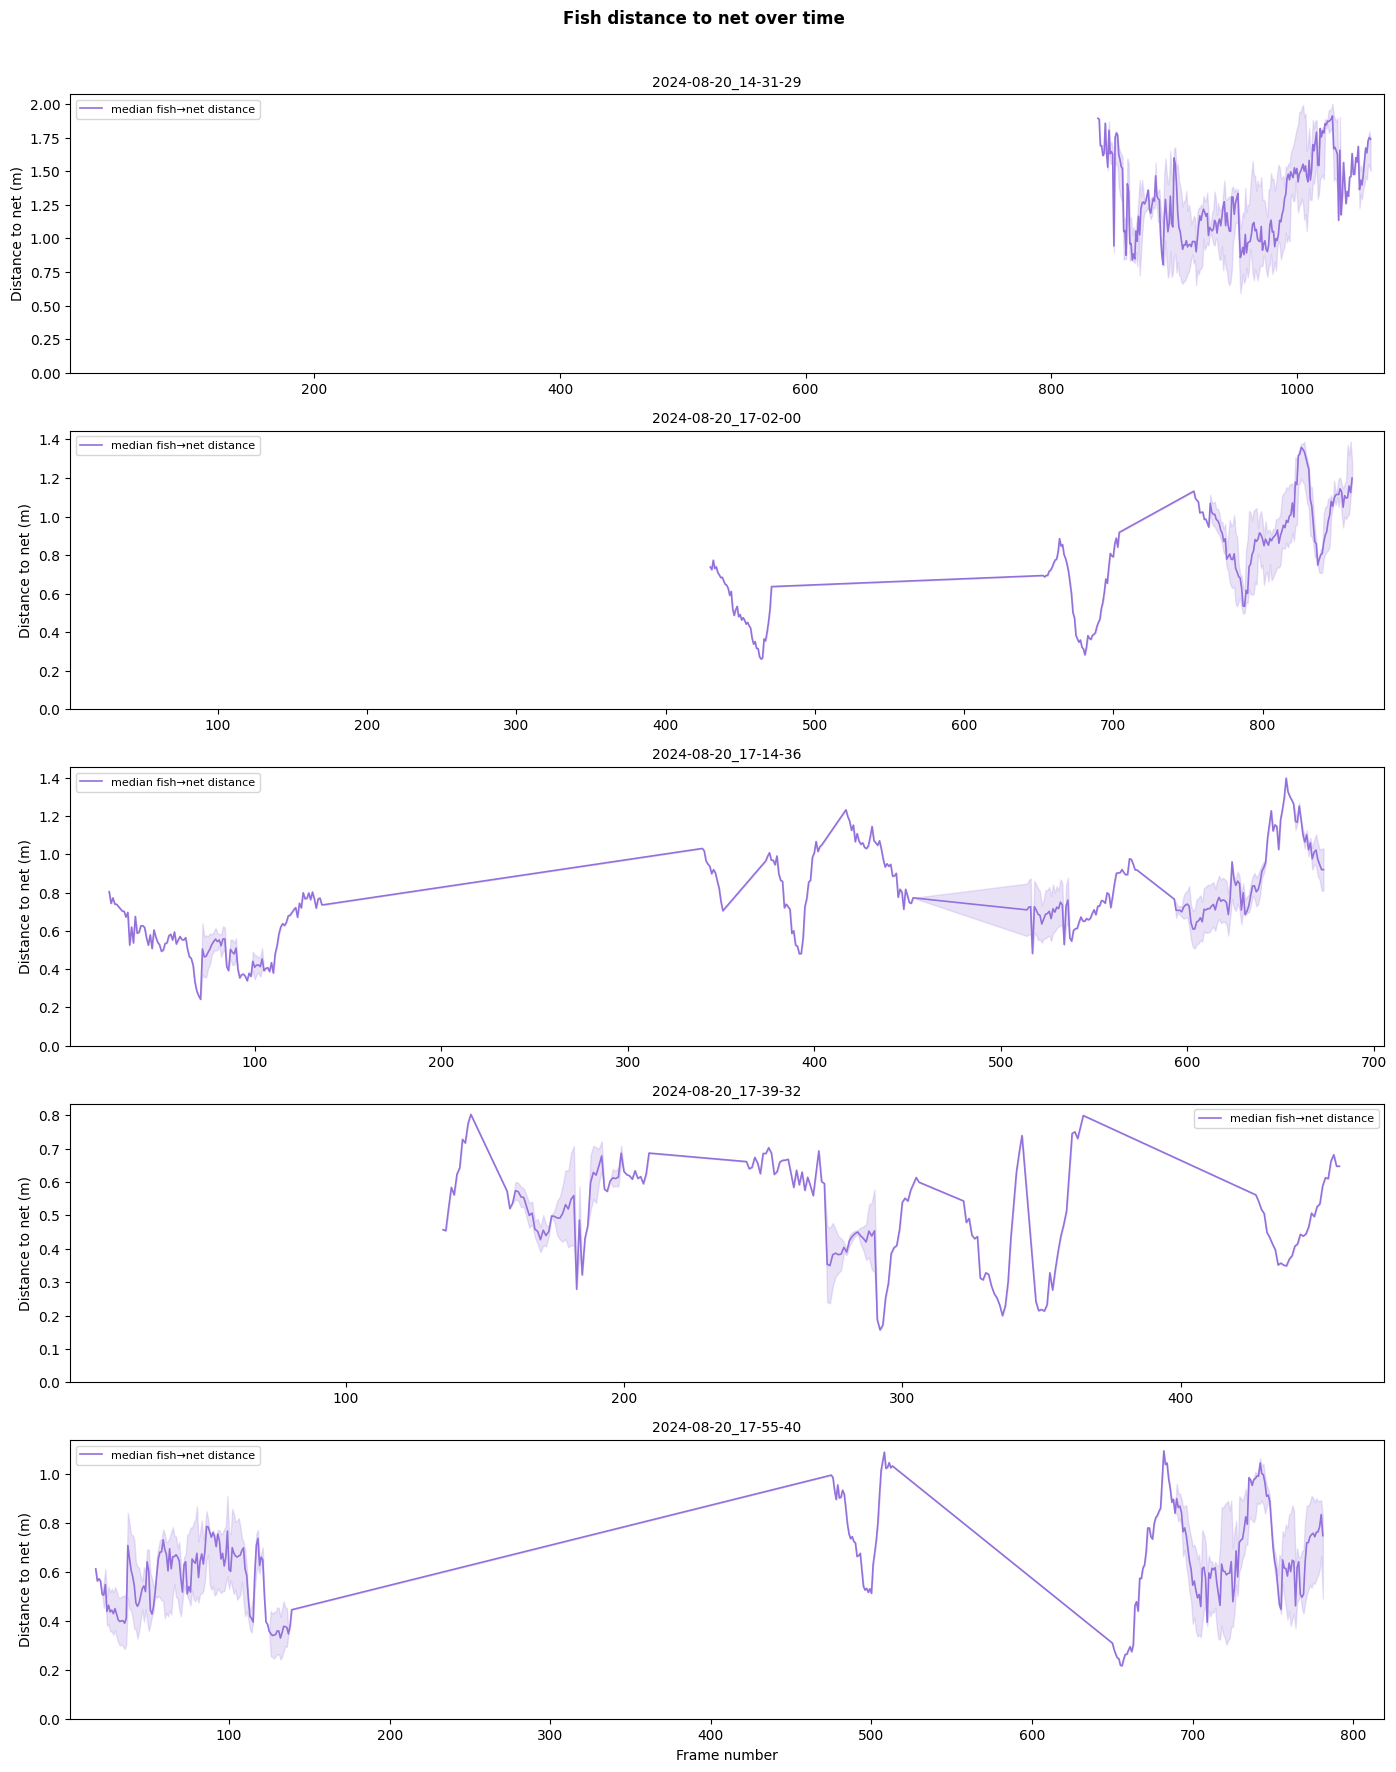

In [12]:
fig, axes = plt.subplots(len(all_dfs), 1, figsize=(14, 3.5 * len(all_dfs)), sharex=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq  = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1]
    net  = df[df["class_id"] == 2]

    if net.empty or fish.empty:
        ax.set_title(f"{seq} — insufficient data", fontsize=10)
        continue

    net_per_frame = net.groupby("frame_norm")[["x_m", "y_m"]].mean()
    merged = fish.join(net_per_frame, on="frame_norm", rsuffix="_net")
    merged = merged.dropna(subset=["x_m_net", "y_m_net"])
    merged["dist_to_net"] = np.sqrt(
        (merged["x_m"] - merged["x_m_net"])**2 +
        (merged["y_m"] - merged["y_m_net"])**2
    )

    med = merged.groupby("frame_norm")["dist_to_net"].median()
    q25 = merged.groupby("frame_norm")["dist_to_net"].quantile(0.25)
    q75 = merged.groupby("frame_norm")["dist_to_net"].quantile(0.75)

    ax.fill_between(med.index, q25.values, q75.values, alpha=0.2, color="mediumpurple")
    ax.plot(med.index, med.values, lw=1.2, color="mediumpurple", label="median fish→net distance")
    ax.set_ylabel("Distance to net (m)")
    ax.set_title(seq, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(left=1)
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Frame number")
fig.suptitle("Fish distance to net over time", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fish_distance_to_net.png", dpi=150, bbox_inches="tight")
plt.show()

## 9  Kinematics — speed and heading (top-down)

In [13]:
def compute_kinematics(df: pd.DataFrame) -> pd.DataFrame:
    fish = df[df["class_id"] == 1].sort_values(["track_id", "frame_norm"]).copy()
    fish["dx_m"]   = fish.groupby("track_id")["x_m"].diff()
    fish["dy_m"]   = fish.groupby("track_id")["y_m"].diff()
    fish["dframe"] = fish.groupby("track_id")["frame_norm"].diff()
    fish = fish[fish["dframe"] <= 2].copy()  # drop large gaps
    fish["speed_m_fr"] = np.sqrt(fish["dx_m"]**2 + fish["dy_m"]**2) / fish["dframe"]
    fish["angle"]      = np.arctan2(fish["dx_m"], -fish["dy_m"])  # 0° = toward sonar (up)
    return fish.dropna(subset=["speed_m_fr"])

kin_dfs = [compute_kinematics(df) for df in all_dfs]
kin_all = pd.concat(kin_dfs, ignore_index=True)
print(f"Kinematic steps: {len(kin_all):,}")
print(f"Speed (m/frame): mean={kin_all['speed_m_fr'].mean():.4f}  "
      f"median={kin_all['speed_m_fr'].median():.4f}  "
      f"p95={kin_all['speed_m_fr'].quantile(0.95):.4f}")

Kinematic steps: 2,774
Speed (m/frame): mean=0.0496  median=0.0385  p95=0.1283


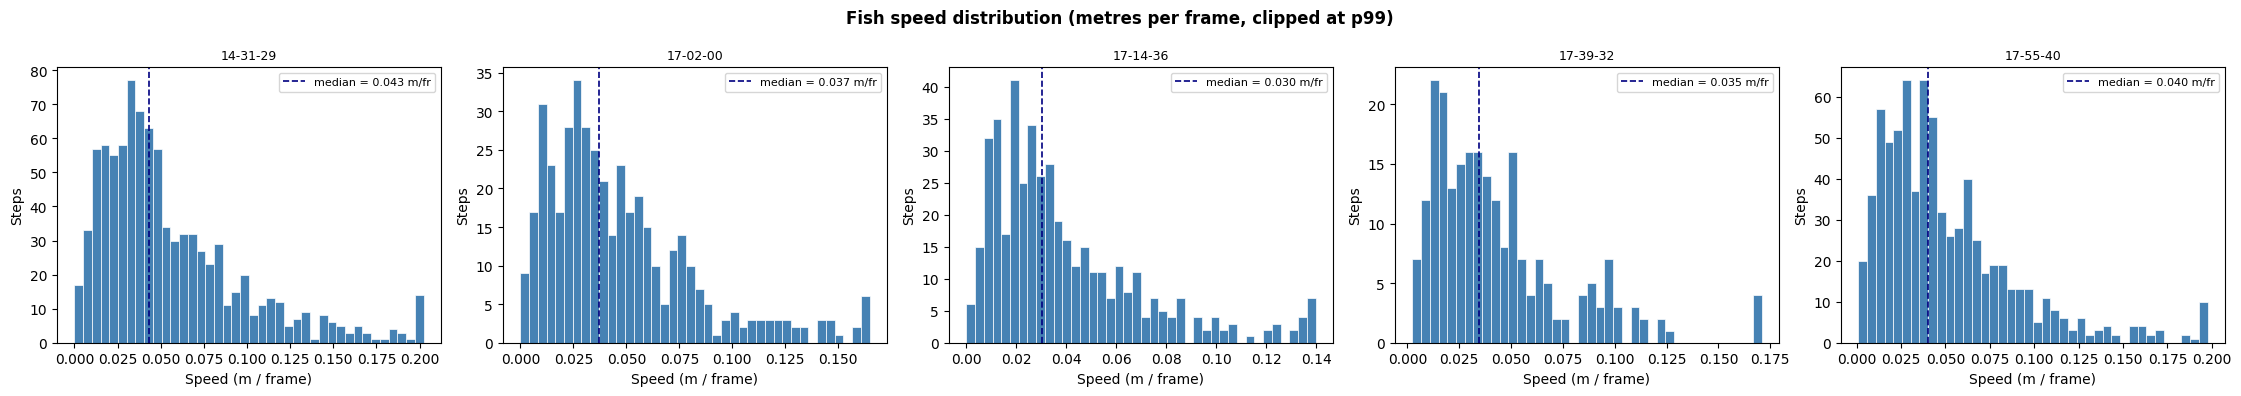

In [14]:
fig, axes = plt.subplots(1, len(kin_dfs), figsize=(4.5 * len(kin_dfs), 4))
if len(kin_dfs) == 1:
    axes = [axes]

for ax, kdf in zip(axes, kin_dfs):
    seq    = kdf["sequence"].iloc[0]
    speeds = kdf["speed_m_fr"].clip(upper=kdf["speed_m_fr"].quantile(0.99))
    ax.hist(speeds, bins=40, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.axvline(speeds.median(), color="navy", ls="--", lw=1.2,
               label=f"median = {speeds.median():.3f} m/fr")
    ax.set_xlabel("Speed (m / frame)")
    ax.set_ylabel("Steps")
    ax.set_title(seq[-8:], fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Fish speed distribution (metres per frame, clipped at p99)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_speed_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 10  Movement direction — polar histogram (top-down)
0° = swimming toward sonar (upward in image), 180° = swimming away.

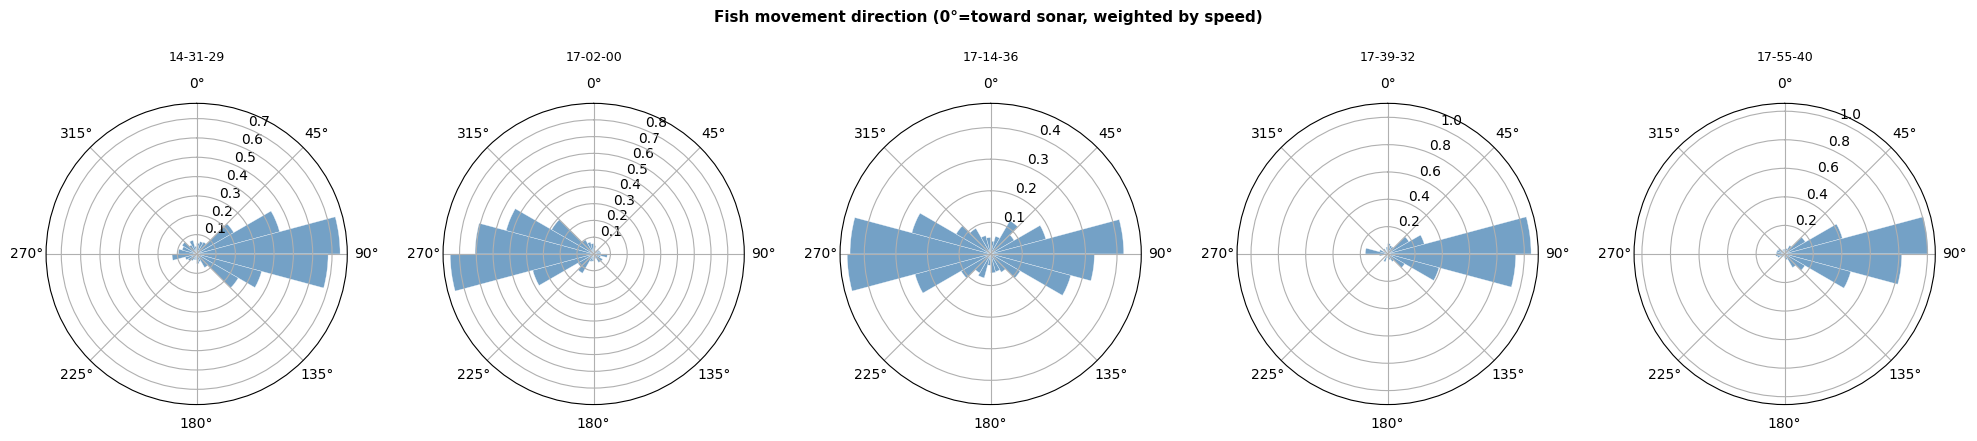

In [15]:
fig, axes = plt.subplots(1, len(kin_dfs), figsize=(4 * len(kin_dfs), 4),
                          subplot_kw={"projection": "polar"})
if len(kin_dfs) == 1:
    axes = [axes]

bins = np.linspace(-np.pi, np.pi, 25)

for ax, kdf in zip(axes, kin_dfs):
    seq     = kdf["sequence"].iloc[0]
    angles  = kdf["angle"].values
    weights = kdf["speed_m_fr"].values
    counts, bin_edges = np.histogram(angles, bins=bins, weights=weights, density=True)
    width   = bin_edges[1] - bin_edges[0]
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.bar(centers, counts, width=width, color="steelblue", alpha=0.75,
           edgecolor="white", linewidth=0.3)
    ax.set_theta_zero_location("N")   # 0° = up = toward sonar
    ax.set_theta_direction(-1)        # clockwise (compass convention)
    ax.set_title(seq[-8:], fontsize=9, pad=12)

fig.suptitle("Fish movement direction (0°=toward sonar, weighted by speed)",
             fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("fish_direction_polar.png", dpi=150, bbox_inches="tight")
plt.show()

## 11  Net track activity timelines

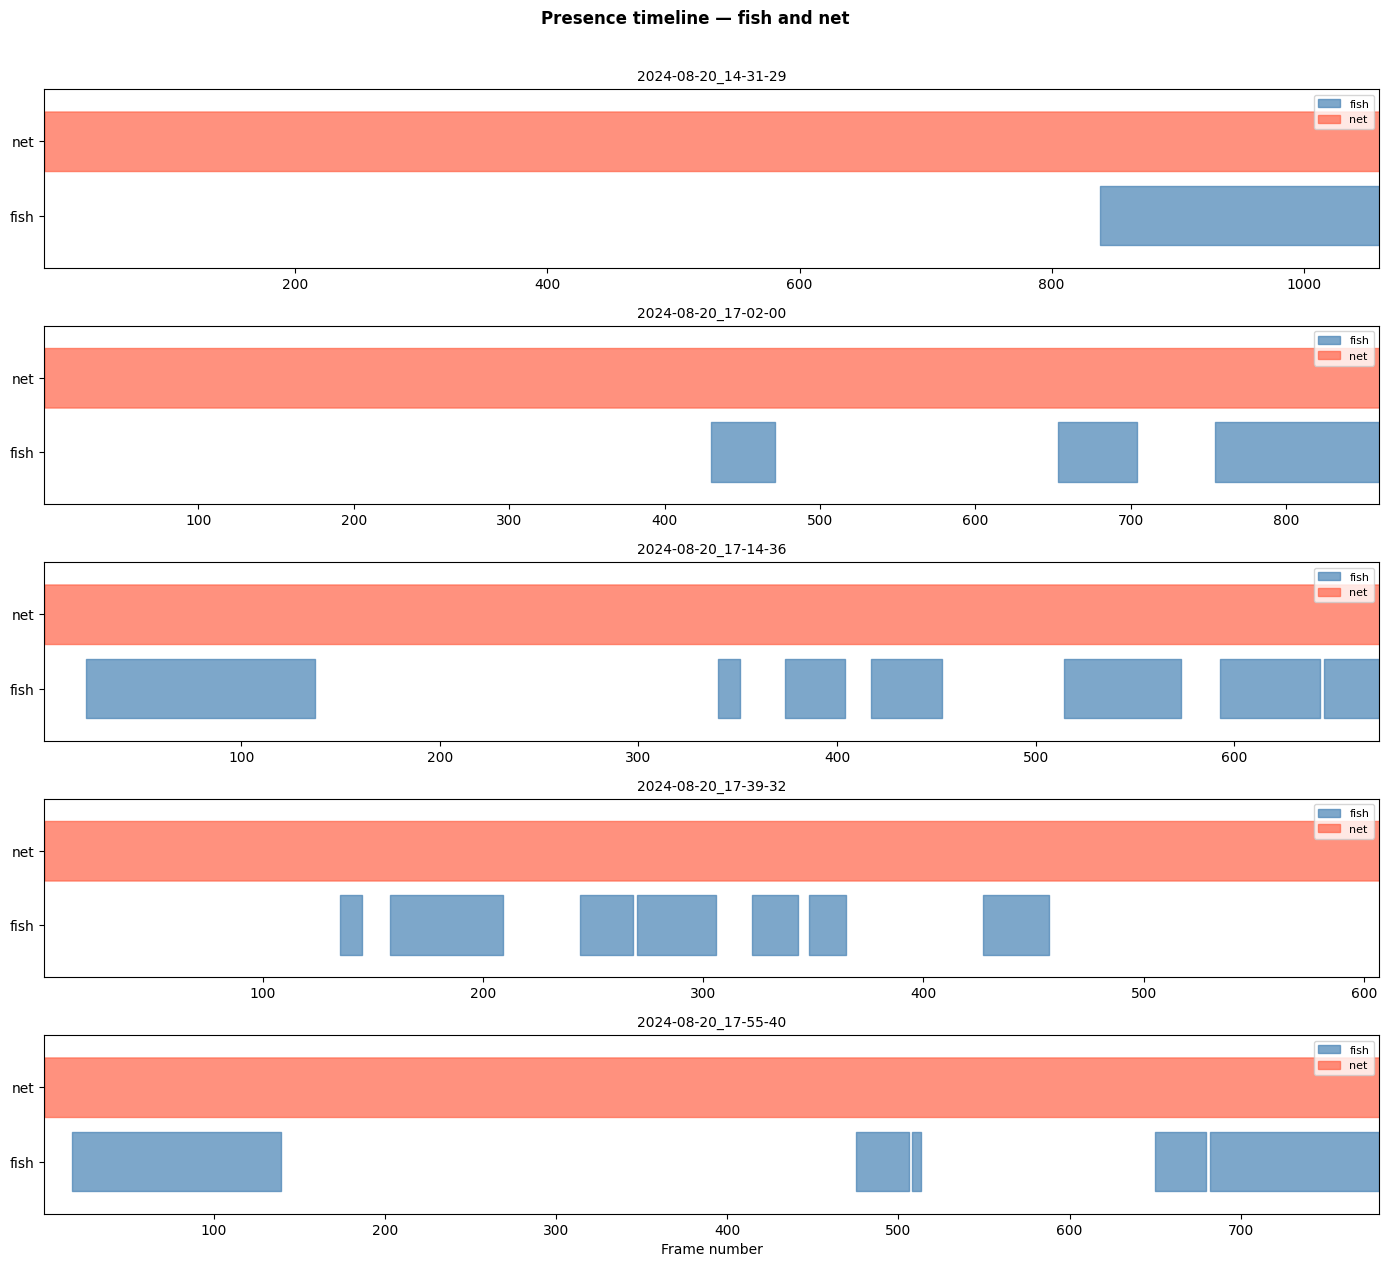

In [16]:
fig, axes = plt.subplots(len(all_dfs), 1, figsize=(14, 2.5 * len(all_dfs)), sharex=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq   = df["sequence"].iloc[0]
    total = int(df["total_frames"].iloc[0])
    all_frames = pd.Series(range(1, total + 1), name="frame_norm")

    for cls, color, label in [(1, "steelblue", "fish"), (2, "tomato", "net")]:
        present = df[df["class_id"] == cls].groupby("frame_norm").size().reindex(all_frames, fill_value=0) > 0
        ax.fill_between(present.index, cls - 0.4, cls + 0.4,
                        where=present.values, color=color, alpha=0.7, label=label)

    ax.set_yticks([1, 2])
    ax.set_yticklabels(["fish", "net"])
    ax.set_xlim(1, total)
    ax.set_ylim(0.3, 2.7)
    ax.set_title(seq, fontsize=10)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Frame number")
fig.suptitle("Presence timeline — fish and net", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("presence_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 12  Cross-sequence comparison

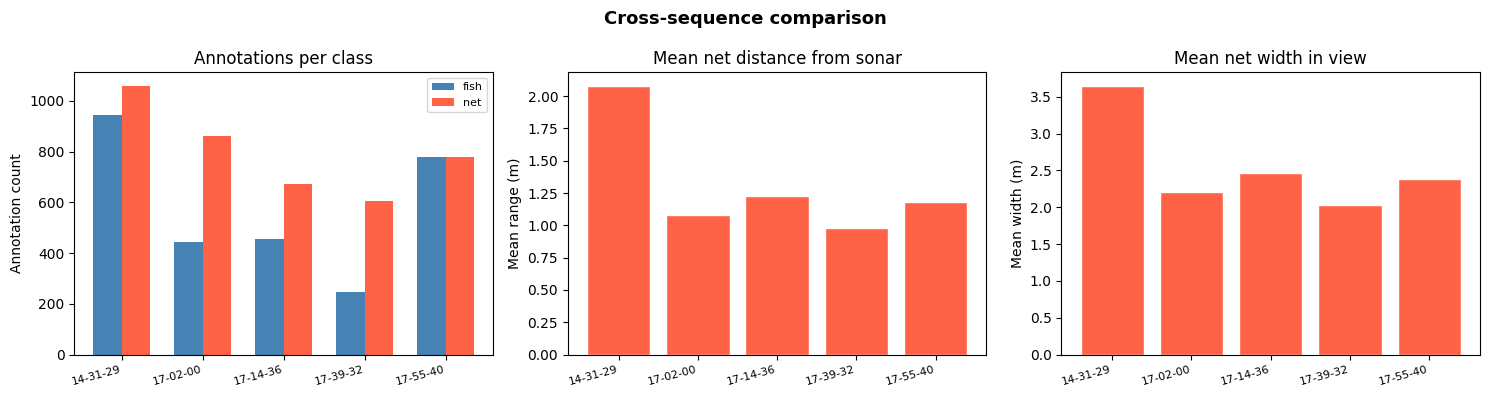

In [17]:
seq_names = [s[-8:] for s in summary["Sequence"]]
x = np.arange(len(seq_names))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fish vs net annotation counts
ax = axes[0]
ax.bar(x - w/2, summary["Fish annots"], w, label="fish", color="steelblue")
ax.bar(x + w/2, summary["Net annots"],  w, label="net",  color="tomato")
ax.set_xticks(x); ax.set_xticklabels(seq_names, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Annotation count")
ax.set_title("Annotations per class")
ax.legend(fontsize=8)

# Mean net range
ax = axes[1]
ax.bar(x, summary["Net range mean (m)"], color="tomato", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(seq_names, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Mean range (m)")
ax.set_title("Mean net distance from sonar")

# Mean net width
ax = axes[2]
ax.bar(x, summary["Net width mean (m)"], color="tomato", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(seq_names, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Mean width (m)")
ax.set_title("Mean net width in view")

fig.suptitle("Cross-sequence comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cross_sequence.png", dpi=150, bbox_inches="tight")
plt.show()